In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor

In [ ]:
data = pd.read_csv("Offshore_official_data_incl_prices.csv")


In [18]:
data.head()

,Unnamed: 0,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,...,emission,emissionfactor,correct_days,date,month,week_number,max_capacity,log_volume,ratio_VC,prijs_excl_belastingen
0,2017-01-01 00:00:00,20170101,0,213.586816,85.714286,86.428571,10206.75,95.714286,2017-01-01-01,873501,...,0,0,2017-01-01-01,2017-01-01,2017-01,1,861300.638701,13.680266,1.014165,0.0420
1,2017-01-01 01:00:00,20170101,1,210.905296,87.142857,90.714286,10199.75,96.142857,2017-01-01-02,883749,...,0,0,2017-01-01-02,2017-01-01,2017-01,1,861299.242185,13.691929,1.026065,0.0499
2,2017-01-01 02:00:00,20170101,2,208.585001,89.285714,87.857143,10191.50,96.000000,2017-01-01-03,872500,...,0,0,2017-01-01-03,2017-01-01,2017-01,1,861299.705697,13.679119,1.013004,0.0520
3,2017-01-01 03:00:00,20170101,3,209.977979,90.000000,90.000000,10182.25,96.142857,2017-01-01-04,889750,...,0,0,2017-01-01-04,2017-01-01,2017-01,1,861300.397937,13.698697,1.033031,0.0410
4,2017-01-01 04:00:00,20170101,4,208.541568,89.285714,87.142857,10176.25,95.571429,2017-01-01-05,893251,...,0,0,2017-01-01-05,2017-01-01,2017-01,1,861301.078959,13.702624,1.037095,0.0390


In [19]:
len(data)

70128

In [20]:
X = data.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume"], #are always 0 and can be ignored
                      axis=1)

# our target variable
y = data["volume"]
y_log = data["log_volume"]
X_train = X[X["date"] < "2024-01-01"]
X_test = X[X["date"] >= "2024-01-01"]

# Label
y_train = y[:X_train.shape[0]] #list slice: from beginning to end of X-train
y_test = y[X_train.shape[0]:] #list slice: from end of X-train to the end of the data
y_train_log = y_log[:X_train.shape[0]]
y_test_log = y_log[X_train.shape[0]:]

In [21]:
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test.shape)
print(y_train_log.shape)
print(y_test_log.shape)

(61344, 17)
(61344,)
(8784,)
(8784, 17)
(61344,)
(8784,)


In [81]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "max_capacity", 
                    "prijs_excl_belastingen"]
X_train_p = X_train.loc[:, numeric_features]
X_test_p = X_test.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm_p = preprocessor.fit_transform(X_train_p)
X_test_norm_p = preprocessor.fit_transform(X_test_p)
X_train_p = pd.DataFrame(X_train_norm_p, columns=X_train_p.columns.values, index=X_train_p.index.values)
X_test_p = pd.DataFrame(X_test_norm_p, columns = X_test_p.columns.values, index=X_test_p.index.values)


In [83]:
print(X_train_p.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test_p.shape)
print(y_train_log.shape)
print(y_test_log.shape)

(61344, 8)
(61344,)
(8784,)
(8784, 8)
(61344,)
(8784,)


In [10]:
param_grid = {
    'max_depth': [3, 5],
    'n_estimators': [50]
}
model = XGBRegressor()
grid = GridSearchCV(model, param_grid=param_grid, cv=3)
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             param_grid={'max_depth': [3, 5], 'n_estimators': [50]})

In [84]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_p.fit(X_train_p, y_train) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_p = cv_XGB_p.best_estimator_
XGB_pred_p = XGB_model_p.predict(X_test_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test, XGB_pred_p))


Mean cross-validated score of the best_estimator: 0.957504908478928
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  1980607101796.6553


In [14]:
399,313,401,394.6672 - 1,980,607,101,796.6553 #non price data - price data

(399, 313, 401, 393.6672, 980, 607, 101, 796.6553)

# Logged version

In [ ]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_log_p.fit(X_train_p, y_train_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_log_p = cv_XGB_log_p.best_estimator_
XGB_pred_log_p = XGB_model_log_p.predict(X_test_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_log, XGB_pred_log_p))


Mean cross-validated score of the best_estimator: 0.957504908478928
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  1.2011726038101698


In [63]:
x_axis_train = data["date"][:len(y_train_log)]
x_axis_test = data["date"][len(y_train_log):]
x_axis_train[0:5]
print(len(x_axis_train))
print(len(x_axis_test))

61344
8784


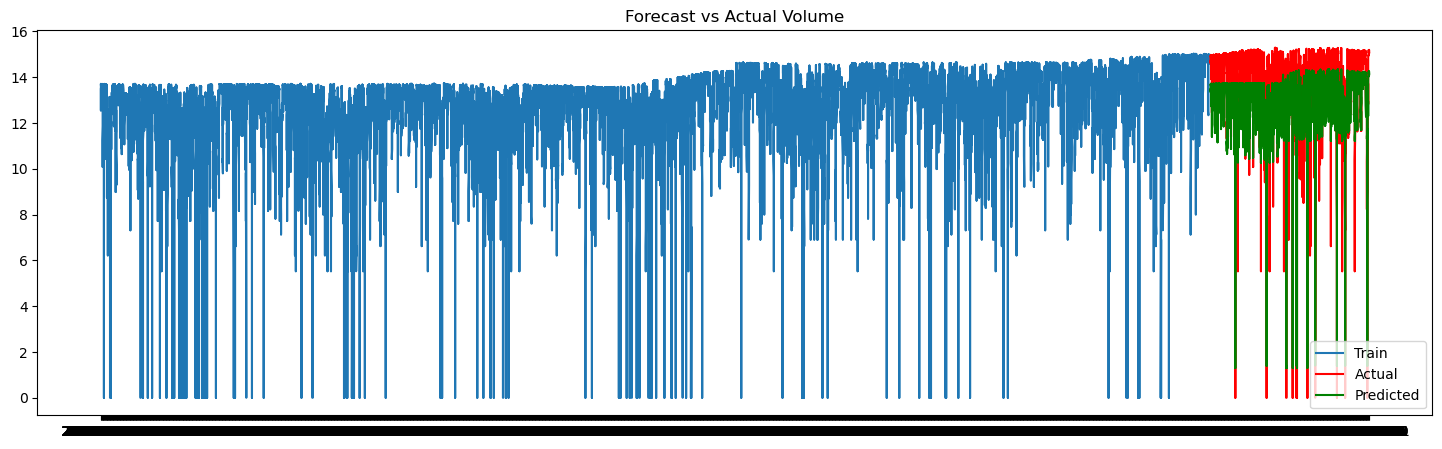

In [ ]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train, y_train_log, label="Train")
plt.plot(x_axis_test, y_test_log, label="Actual", color='red')
plt.plot(x_axis_test, XGB_pred_log_p, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Monthly

In [58]:
# Convert hourly data to monthly data
db_monthly = data.groupby('month').mean(numeric_only=True)
# Split into train and test set
train_db = db_monthly[db_monthly.index <= '2024-06']
test_db = db_monthly[db_monthly.index > '2024-06']

X_month = db_monthly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC"], #are always 0 and can be ignored
                      axis=1)

# our target variable
y_month_log = db_monthly["log_volume"]
y_month = db_monthly["volume"]

# Features
X_train_month = X_month[X_month.index <= '2024-06']
X_test_month = X_month[(X_month.index > '2024-06')]


# Label log
y_train_month_log = y_month_log[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month_log = y_month_log[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data

# Label
y_train_month = y_month[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month = y_month[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data



In [59]:
print(X_train_month.shape)
print(X_test_month.shape)
print(y_train_month.shape)
print(y_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)

(90, 11)
(6, 11)
(90,)
(6,)
(90,)
(6,)


In [60]:
print(X_train_month["prijs_excl_belastingen"].dtype)

float64


In [61]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "max_capacity", "prijs_excl_belastingen"]
X_train_month_p = X_train_month.loc[:, numeric_features]
X_test_month_p = X_test_month.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_month_p = preprocessor.fit_transform(X_train_month_p)
X_test_norm_month_p = preprocessor.fit_transform(X_test_month_p)


In [62]:
#add feature names back 
X_train_month = pd.DataFrame(X_train_norm_month_p, columns=X_train_month_p.columns.values, index=X_train_month_p.index.values)

X_test_month = pd.DataFrame(X_test_norm_month_p, columns = X_test_month_p.columns.values, index=X_test_month_p.index.values)

X_train_month_p.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,max_capacity,prijs_excl_belastingen
month,,,,,,,,
2017-01,196.375016,60.767808,60.876896,10221.063284,85.399002,0.492582,861302.839850,0.048947
2017-02,165.060252,75.307011,75.433870,10144.316964,87.309524,0.643716,861299.976699,0.037910
2017-03,192.136378,64.632882,64.570503,10148.379704,82.628616,0.468991,861298.459539,0.035396
2017-04,246.010039,59.629983,59.720950,10207.336458,76.329193,0.424904,861301.625732,0.036176
2017-05,167.815843,56.497474,56.531968,10172.097222,77.467198,0.356803,861300.345436,0.035614


In [63]:
print(X_train_month_p.shape)
print(X_test_month_p.shape)
print(y_train_month.shape)
print(y_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)

(90, 8)
(6, 8)
(90,)
(6,)
(90,)
(6,)


In [64]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month_log_p.fit(X_train_month_p, y_train_month_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month_log_p = cv_XGB_month_log_p.best_estimator_
XGB_pred_month_log_p = XGB_model_month_log_p.predict(X_test_month_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month_log, XGB_pred_month_log_p))

Mean cross-validated score of the best_estimator: 0.6431481835570214
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  0.49420418392495685


In [65]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month_p.fit(X_train_month_p, y_train_month) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month_p = cv_XGB_month_p.best_estimator_
XGB_pred_month_p = XGB_model_month_p.predict(X_test_month_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month, XGB_pred_month_p))


Mean cross-validated score of the best_estimator: 0.5563393402720045
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  570403129063.3673


NameError: name 'y_train_month' is not defined

# Weekly

In [66]:
# Convert hourly data to weekly data
db_weekly = data.groupby('week_number').mean(numeric_only=True)

X_week = db_weekly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC"], #are always 0 and can be ignored
                      axis=1)


# our target variable
y_week = db_weekly["volume"]
y_week_log = db_weekly["log_volume"]

# Features
X_train_week = X_week[X_week.index <= 406]
X_test_week = X_week[(X_week.index > 406)]

# Label
y_train_week = y_week[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week = y_week[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

# Label Log
y_train_week_log = y_week_log[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week_log = y_week_log[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

In [67]:
print(X_train_week.shape)
print(X_test_week.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 10)
(12, 10)
(406,)
(12,)
(406,)
(12,)


In [68]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "max_capacity", "prijs_excl_belastingen"]
X_train_week_p = X_train_week.loc[:, numeric_features]
X_test_week_p = X_test_week.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_week_p = preprocessor.fit_transform(X_train_week_p)
X_test_norm_week_p = preprocessor.fit_transform(X_test_week_p)

In [69]:
#add feature names back 
X_train_week_p = pd.DataFrame(X_train_norm_week_p, columns=X_train_week_p.columns.values, index=X_train_week_p.index.values)

X_test_week_p = pd.DataFrame(X_test_norm_week_p, columns = X_test_week_p.columns.values, index=X_test_week_p.index.values)

X_train_week_p.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,max_capacity,prijs_excl_belastingen
1,0.964307,0.791946,0.793976,1.316377,0.003672,1.183927,-0.965738,-0.610106
2,1.276994,1.146825,1.148706,-0.582877,0.539061,0.919688,-0.965738,-0.587360
3,-1.000973,-1.948013,-1.950196,2.286471,0.994825,-1.434145,-0.965729,-0.365025
4,-0.338505,-1.304255,-1.299511,1.138929,0.962738,-0.665767,-0.965731,-0.384954
5,-0.968562,-0.336506,-0.348301,-0.765821,1.449451,0.530952,-0.965738,-0.525912


In [70]:
print(X_train_week_p.shape)
print(X_test_week_p.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 8)
(12, 8)
(406,)
(12,)
(406,)
(12,)


In [71]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week_p.fit(X_train_week_p, y_train_week) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week_p = cv_XGB_week_p.best_estimator_
XGB_pred_week_p = XGB_model_week_p.predict(X_test_week_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week, XGB_pred_week_p))


Mean cross-validated score of the best_estimator: 0.8625119932658366
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  1862076559138.4412


In [72]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week_log_p.fit(X_train_week_p, y_train_week_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week_log_p = cv_XGB_week_log_p.best_estimator_
XGB_pred_week_log_p = XGB_model_week_log_p.predict(X_test_week_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week_log, XGB_pred_week_log_p))

Mean cross-validated score of the best_estimator: 0.825978974846695
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  1.4293384079192555


# Daily

In [73]:
data['date2'] = pd.to_datetime(data['date'], format='ISO8601')
db_daily = data.groupby('date2').mean(numeric_only=True)
# Split into train and test set
db_daily.index = pd.to_datetime(db_daily.index)

X_day = db_daily.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC"], #are always 0 and can be ignored
                      axis=1)

#our targer variable
y_day = db_daily["volume"]
y_day_log = db_daily["log_volume"]

# Features
X_train_day = X_day[X_day.index <= '2024-11-01']
X_test_day = X_day[X_day.index > '2024-11-01']

# Label
y_train_day = y_day[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day = y_day[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data

# Label log
y_train_day_log = y_day_log[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day_log = y_day_log[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data

In [74]:
print(X_train_day.shape)
print(X_test_day.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 11)
(60, 11)
(2862,)
(60,)
(2862,)
(60,)


In [75]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "max_capacity", "prijs_excl_belastingen"]
X_train_day_p = X_train_day.loc[:, numeric_features]
X_test_day_p = X_test_day.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm_day_p = preprocessor.fit_transform(X_train_day_p)
X_test_norm_day_p = preprocessor.fit_transform(X_test_day_p)

In [76]:
#add feature names back 
X_train_day_p = pd.DataFrame(X_train_norm_day_p, columns=X_train_day_p.columns.values, index=X_train_day_p.index.values)
X_test_day_p = pd.DataFrame(X_test_norm_day_p, columns = X_test_day_p.columns.values, index=X_test_day_p.index.values)
X_train_day_p.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,max_capacity,prijs_excl_belastingen
2017-01-01,0.488074,0.556012,0.521860,0.216443,1.499439,0.987147,-0.96055,-0.499744
2017-01-02,1.798048,0.240440,0.263189,0.784597,-0.778009,1.203956,-0.96055,-0.429699
2017-01-03,1.069091,1.144447,1.178031,0.489462,0.372303,1.536339,-0.96055,-0.581776
2017-01-04,1.791723,1.977036,1.966069,0.195717,-1.044870,1.625063,-0.96055,-0.619618
2017-01-05,-1.235953,-0.349893,-0.368855,1.768675,-0.968323,-0.250306,-0.96055,-0.586246


In [77]:
print(X_train_day_p.shape)
print(X_test_day_p.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 8)
(60, 8)
(2862,)
(60,)
(2862,)
(60,)


In [78]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day_p.fit(X_train_day_p, y_train_day) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day_p = cv_XGB_day_p.best_estimator_
XGB_pred_day_p = XGB_model_day_p.predict(X_test_day_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day, XGB_pred_day_p))

Mean cross-validated score of the best_estimator: 0.9159246982560152
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  2722829762737.2886


In [80]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day_log_p.fit(X_train_day_p, y_train_day_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day_log_p = cv_XGB_day_log_p.best_estimator_
XGB_pred_day_log_p = XGB_model_day_log_p.predict(X_test_day_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day_log, XGB_pred_day_log_p))

Mean cross-validated score of the best_estimator: 0.8850623528735724
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  2.6598787941753077
